# 🦴 PENGWIN — notebook de control del pipeline

Este notebook **no contiene el código del modelo**: llama a los scripts de `scripts/` y a las
funciones de `src/`. El código vive en un solo lugar (el que se revisa en los Pull Requests)
y el notebook solo orquesta, muestra resultados y deja las gráficas para el informe.

> Si algo necesita cambiarse, se cambia en `src/` o en `configs/`, **no aquí**. Así el notebook
> nunca queda desincronizado con lo que se entrega.

**Cómo usarlo**
1. Ajusta la celda de **Parámetros**. Por defecto trabaja con los datos reales, no rehace la caché
   ni entrena: sirve para ver resultados, evaluar y visualizar sin tocar lo que ya existe.
   `MODO_PRUEBA = True` solo para comprobar una instalación nueva; escribe en carpetas aparte.
2. Corre las secciones en orden. Cada sección corresponde a una semana del cronograma.
3. Los entrenamientos largos se lanzan desde la terminal (sección 4).

| Sección | Semana | Qué hace |
|---|---|---|
| 0 | — | entorno, GPU, configuración |
| 1 | 8 | datos: caché + splits por paciente |
| 2 | 8 | EDA + visualizador 1 (MIP raw) |
| 3 | 9 | memoria, overfit test, calibración de λ |
| 4 | 9–10 | entrenamiento por etapas |
| 5 | 10 | evaluación (métricas sección 5 + robustez) |
| 6 | 10–11 | inferencia + visualizadores 2 y 3 |
| 7 | 10 | baseline SAM |
| 8 | 11 | dashboard + túnel de Cloudflare |

⚠️ **Uso exclusivamente académico.** No es un dispositivo médico ni está validado clínicamente.

## 0 · Parámetros y entorno

In [ ]:
# ============================ PARAMETROS ============================
MODO_PRUEBA   = False       # True: solo para verificar la instalacion con CT sinteticos (carpetas aparte)
NOMBRE_EXP    = "completo"  # carpeta de checkpoints/resultados: "completo", "sin_cbam", "con_tl"
CONFIG_BASE   = "configs/default.yaml"  # ablaciones: configs/ablacion_sin_cbam.yaml, configs/ablacion_con_tl.yaml
DEVICE        = None        # None = GPU si hay, si no CPU

REHACER_DATOS = False       # True solo para reconstruir cache, splits y EDA
ENTRENAR      = False       # los entrenamientos largos se corren desde la terminal
CORRER_PRUEBAS = False      # perfil de memoria, overfit test y calibracion de lambdas (seccion 3)
EVALUAR       = False       # evaluacion completa sobre test (seccion 5), usa la GPU varios minutos

# Rutas del dataset real (solo si MODO_PRUEBA = False).
# Las imagenes de part1.zip y part2.zip van en la MISMA carpeta.
RUTA_IMAGENES  = "data/raw/images"
RUTA_ETIQUETAS = "data/raw/labels"

# Colab: carpeta de Google Drive donde subieron los 3 zip de Zenodo
DRIVE_ZIPS = "/content/drive/MyDrive/PENGWIN"
# ====================================================================

In [ ]:
import os, sys, subprocess, json, shutil
from pathlib import Path

ENTORNO = "colab" if "google.colab" in sys.modules else ("kaggle" if Path("/kaggle").exists() else "local")
REPO_URL = "https://github.com/ShadowBlack33/Proyecto-2-Analitica-de-Datos.git"

if ENTORNO == "local":
    # el notebook vive en notebooks/: se trabaja desde la raiz del repo
    if Path.cwd().name == "notebooks":
        os.chdir("..")
else:
    base = Path("/content") if ENTORNO == "colab" else Path("/kaggle/working")
    repo = base / "Proyecto-2-Analitica-de-Datos"
    if not repo.exists():
        subprocess.run(["git", "clone", "-q", REPO_URL, str(repo)], check=True)
    os.chdir(repo)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "SimpleITK", "streamlit", "medpy"], check=False)

RAIZ = Path.cwd()
assert (RAIZ / "src").exists() and (RAIZ / "configs").exists(), f"No estoy en la raiz del repo: {RAIZ}"
sys.path.insert(0, str(RAIZ))
print("entorno:", ENTORNO, "| raiz:", RAIZ)

entorno: local | raiz: c:\Users\Carlo\Downloads\Analitica\Proyecto-2-Analitica\pengwin-repo-organizado


In [ ]:
def correr(*args):
    """Corre un script con EL MISMO Python de este kernel (sys.executable).
    En Windows, `!python` puede usar otro Python distinto al del venv del kernel;
    esto lo evita. Muestra la salida en vivo y se detiene si el script falla."""
    cmd = [sys.executable, *[str(a) for a in args]]
    print("$", " ".join(cmd[1:]))
    p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True,
                         encoding="utf-8", errors="replace", cwd=RAIZ)
    for linea in p.stdout:
        print(linea, end="")
    if p.wait() != 0:
        raise RuntimeError(f"fallo: {' '.join(cmd[1:])}")

import torch
print("PyTorch", torch.__version__)
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"GPU: {p.name} · {p.total_memory / 1024**3:.1f} GB")
else:
    print("Sin GPU: todo corre en CPU (lento para entrenar, suficiente para probar)")

PyTorch 2.6.0+cu124
GPU: NVIDIA GeForce RTX 3060 Laptop GPU · 6.0 GB


### Configuración del experimento
Se parte de `configs/default.yaml` y se escribe `configs/notebook.yaml` con las rutas de este
entorno. `default.yaml` no se toca desde aquí: es la configuración oficial que cita el informe.

In [ ]:
import yaml
from src.utils import cargar_config

cfg = cargar_config(CONFIG_BASE)

if MODO_PRUEBA:
    cfg["rutas"]["imagenes"]  = "data/sintetico/images"
    cfg["rutas"]["etiquetas"] = "data/sintetico/labels"
    cfg["rutas"]["cache"]     = "data/cache_sintetico"
    cfg["rutas"]["splits"]    = "data/splits_sintetico.json"
    cfg["rutas"]["checkpoints"] = "checkpoints/prueba_sintetica"
    cfg["rutas"]["resultados"]  = "resultados/prueba_sintetica"
    ENTRENAR, EVALUAR, CORRER_PRUEBAS = True, True, True
    # prueba rapida: resolucion baja y pocas epocas
    cfg["datos"]["resolucion"] = 128
    cfg["entrenamiento"]["batch_size"] = 4
    for etapa, ep in zip(cfg["entrenamiento"]["etapas"], [3, 3, 1, 1]):
        etapa["epocas"] = ep
else:
    cfg["rutas"]["imagenes"]  = RUTA_IMAGENES
    cfg["rutas"]["etiquetas"] = RUTA_ETIQUETAS

CONFIG = "configs/notebook.yaml"
with open(CONFIG, "w", encoding="utf-8") as f:
    yaml.safe_dump(cfg, f, sort_keys=False, allow_unicode=True)

RES = Path(cfg["rutas"]["resultados"])
CKPT_DIR = Path(cfg["rutas"]["checkpoints"]) / NOMBRE_EXP
print("config:", CONFIG, "| imagenes:", cfg["rutas"]["imagenes"])

config: configs/notebook.yaml | imagenes: data/raw/images


## 1 · Datos (semana 8)

**Solo Colab:** copia los zip desde Drive y los descomprime en el disco local de la sesión
(descomprimir directo desde Drive es muy lento). Tarda unos minutos; solo hace falta una vez por sesión.
En local, descomprime los zip a mano en `data/raw/images` y `data/raw/labels`.

In [ ]:
if ENTORNO == "colab" and not MODO_PRUEBA:
    from google.colab import drive
    drive.mount("/content/drive")
    import zipfile
    destino = {"PENGWIN_CT_train_images_part1.zip": RUTA_IMAGENES,
               "PENGWIN_CT_train_images_part2.zip": RUTA_IMAGENES,
               "PENGWIN_CT_train_labels.zip": RUTA_ETIQUETAS}
    for nombre, carpeta in destino.items():
        Path(carpeta).mkdir(parents=True, exist_ok=True)
        print("descomprimiendo", nombre)
        with zipfile.ZipFile(Path(DRIVE_ZIPS) / nombre) as z:
            for m in z.infolist():
                if m.is_dir():
                    continue
                m.filename = Path(m.filename).name   # aplana subcarpetas del zip
                z.extract(m, carpeta)
else:
    print("(se omite: no es Colab o estamos en MODO_PRUEBA)")

(se omite: no es Colab o estamos en MODO_PRUEBA)


In [ ]:
if MODO_PRUEBA:
    correr("scripts/generar_datos_sinteticos.py", "--n", 8, "--salida", "data/sintetico")

n_img = len(list(Path(cfg["rutas"]["imagenes"]).glob("*.mha")))
n_lbl = len(list(Path(cfg["rutas"]["etiquetas"]).glob("*.mha")))
print(f"{n_img} imagenes | {n_lbl} etiquetas")
assert n_img > 0, "No hay volumenes: revisa las rutas de la celda de parametros"

100 imagenes | 100 etiquetas


Caché de cortes 256×256 + splits **por paciente** (nunca por corte) con su hash SHA-256.
Con el dataset real tarda del orden de minutos por lote de casos; se hace una sola vez.

In [ ]:
cache = Path(cfg["rutas"]["cache"])
listos = Path(cfg["rutas"]["splits"]).exists() and cache.exists() and any(cache.iterdir())
if REHACER_DATOS or not listos:
    correr("scripts/preparar_datos.py", "--config", CONFIG)
else:
    print("Datos ya preparados: se usa la cache existente (REHACER_DATOS = True para reconstruirla)")

splits = json.load(open(cfg["rutas"]["splits"]))
print({k: len(v) for k, v in splits["splits"].items()}, "| sha256", splits["sha256"][:16])

Datos ya preparados: se usa la cache existente (REHACER_DATOS = True para reconstruirla)
{'train': 70, 'val': 15, 'test': 15} | sha256 99267ddb2310271e


## 2 · EDA + visualizador 1 (semana 8)

In [ ]:
if REHACER_DATOS or not (RES / "eda" / "eda_casos.csv").exists():
    correr("scripts/eda.py", "--config", CONFIG)
else:
    print("EDA ya calculado: se muestran los resultados guardados (REHACER_DATOS = True para recalcular)")

$ scripts/eda.py --config configs/notebook.yaml
[1/100] 001  401x512x512  sz 0.80mm  frag SA/LI/RI 1/2/1
[2/100] 002  337x276x413  sz 0.80mm  frag SA/LI/RI 2/1/3
[3/100] 003  285x381x512  sz 1.00mm  frag SA/LI/RI 1/4/1
[4/100] 004  224x254x386  sz 1.00mm  frag SA/LI/RI 2/2/2
[5/100] 005  312x512x512  sz 1.00mm  frag SA/LI/RI 1/2/3
[6/100] 006  283x279x426  sz 1.00mm  frag SA/LI/RI 4/1/2
[7/100] 007  317x512x512  sz 1.00mm  frag SA/LI/RI 1/3/3
[8/100] 008  335x512x512  sz 0.80mm  frag SA/LI/RI 1/3/1
[9/100] 009  303x245x415  sz 0.80mm  frag SA/LI/RI 1/1/3
[10/100] 010  350x512x512  sz 0.80mm  frag SA/LI/RI 1/3/1
[11/100] 011  313x512x512  sz 0.80mm  frag SA/LI/RI 1/3/2
[12/100] 012  265x512x512  sz 1.00mm  frag SA/LI/RI 1/3/1
[13/100] 013  375x512x512  sz 0.80mm  frag SA/LI/RI 1/1/3
[14/100] 014  298x329x458  sz 1.00mm  frag SA/LI/RI 2/1/4
[15/100] 015  260x281x479  sz 1.00mm  frag SA/LI/RI 2/3/1
[16/100] 016  235x512x512  sz 1.00mm  frag SA/LI/RI 1/2/3
[17/100] 017  280x512x512  sz 1.0

,id,Z,H,W,spacing_z_mm,spacing_y_mm,spacing_x_mm,hu_min,hu_max,nitidez_lap,ruido_aire_hu,espesor_corte_mm,pixel_mm,n_frag_SA,n_frag_LI,n_frag_RI
0,1,401,512,512,0.8,0.781250,0.781250,-1023,2775,0.162197,24.359830,0.8,0.781250,1,2,1
1,2,337,276,413,0.8,0.824219,0.824219,-1023,4711,0.019566,22.871364,0.8,0.824219,2,1,3
2,3,285,381,512,1.0,0.759766,0.759766,-1023,16709,0.018498,23.433941,1.0,0.759766,1,4,1
3,4,224,254,386,1.0,0.843750,0.843750,-1418,4961,0.025360,23.242065,1.0,0.843750,2,2,2
4,5,312,512,512,1.0,0.896484,0.896484,-1023,4695,0.054580,17.802507,1.0,0.896484,1,2,3


,count,mean,std,min,25%,50%,75%,max
id,100.0,50.500000,29.011492,1.000000,25.750000,50.500000,75.250000,100.000000
Z,100.0,321.060000,43.495227,193.000000,285.750000,326.000000,350.000000,414.000000
H,100.0,427.670000,116.890007,154.000000,299.500000,512.000000,512.000000,512.000000
W,100.0,490.010000,43.315730,322.000000,508.000000,512.000000,512.000000,512.000000
spacing_z_mm,100.0,0.890758,0.108800,0.625000,0.800000,0.801025,1.000000,1.250005
spacing_y_mm,100.0,0.818532,0.079226,0.658203,0.781250,0.797914,0.858000,1.220000
spacing_x_mm,100.0,0.818532,0.079226,0.658203,0.781250,0.797914,0.858000,1.220000
hu_min,100.0,-1489.140000,881.015748,-6211.000000,-2048.000000,-1023.000000,-1023.000000,-1023.000000
hu_max,100.0,5505.090000,7218.223656,1422.000000,1677.000000,2345.500000,5433.750000,47685.000000
nitidez_lap,100.0,0.034657,0.030360,0.009382,0.018425,0.028300,0.035953,0.172268


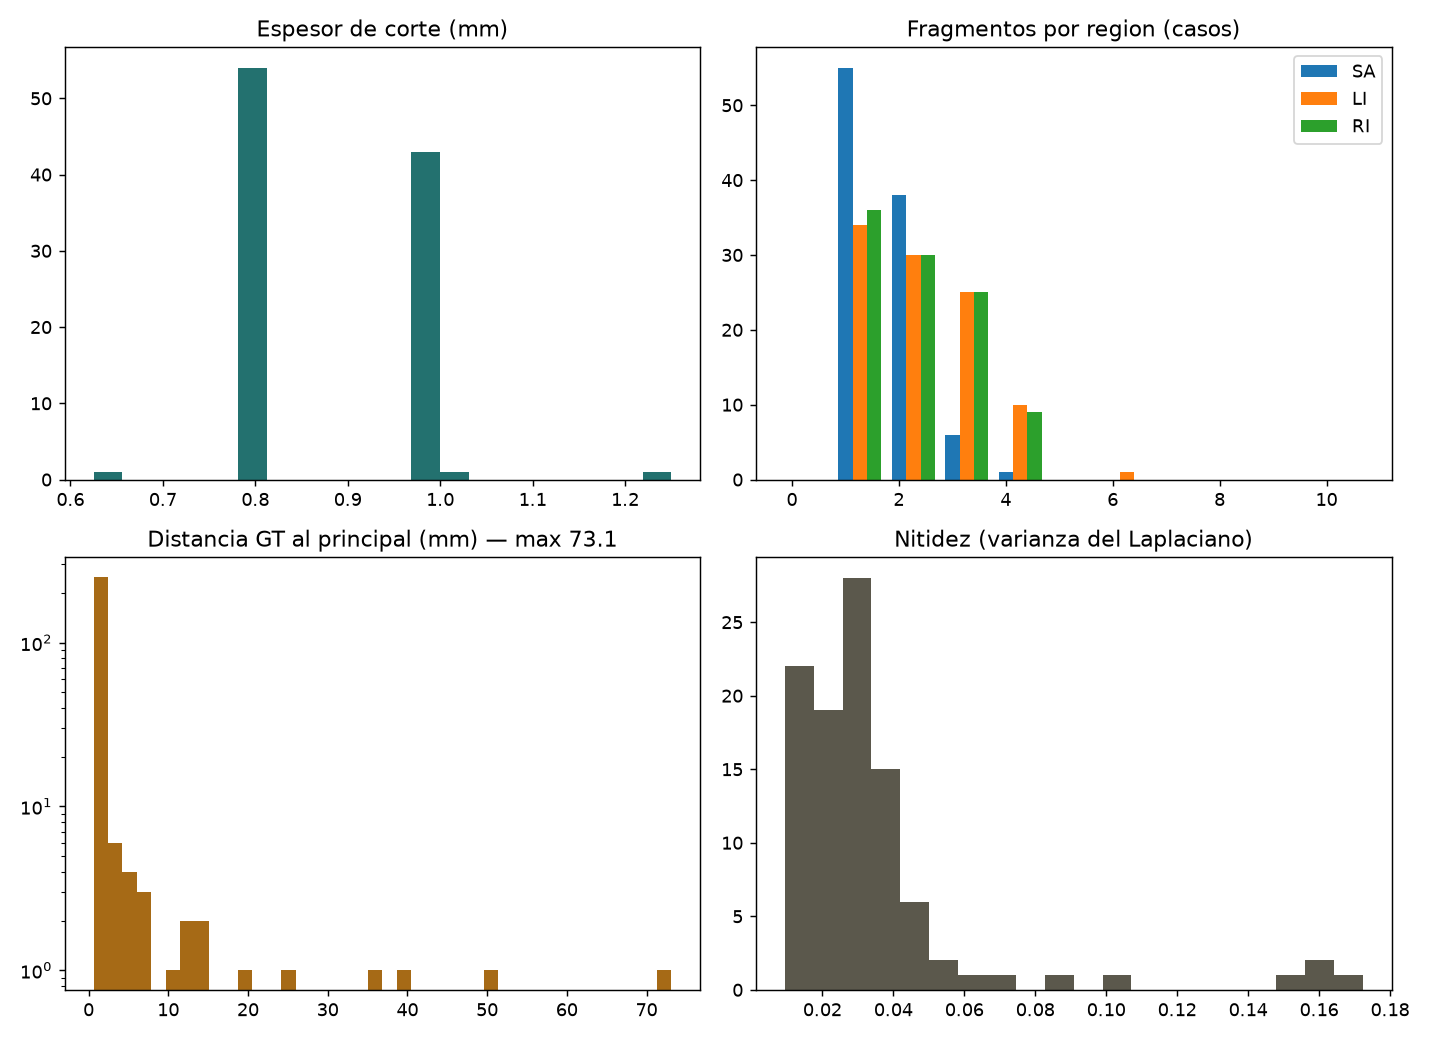

In [ ]:
import pandas as pd
from IPython.display import Image, display

eda_casos = pd.read_csv(RES / "eda" / "eda_casos.csv")
eda_frag  = pd.read_csv(RES / "eda" / "eda_fragmentos.csv")
display(eda_casos.head())
display(eda_casos.describe().T)
if (RES / "eda" / "eda_resumen.png").exists():
    display(Image(str(RES / "eda" / "eda_resumen.png")))

**Qué revisar aquí antes de entrenar** (y anotarlo en la bitácora):
- etiquetas dentro de 0..30 (el script avisa si no);
- rango de distancias GT → confirma el 2 mm–25 cm del profesor y justifica `log(1+d)`;
- percentiles de HU del hueso → ventana HU y umbral del MIP en `configs/default.yaml`;
- spacing en z → por qué toda distancia se mide en mm con el header.

In [ ]:
from src.data.io import leer_volumen, listar_casos
from src.dashboard.visualizadores import vis_mip_raw

casos = listar_casos(cfg["rutas"]["imagenes"], cfg["rutas"]["etiquetas"])
CASO = casos[0]["id"]          # cambia el id para ver otro caso
caso = next(c for c in casos if c["id"] == CASO)
hu, spacing, _ = leer_volumen(caso["imagen"])
print(f"caso {CASO} · forma {hu.shape} · spacing zyx {tuple(round(s, 3) for s in spacing)} mm")

# Visualizador 1: MIP del hueso por umbral de HU (preprocesamiento clasico, sin modelo)
vis_mip_raw(hu, spacing, umbral_hu=cfg["datos"]["umbral_hueso_hu"], angulo=0).show()

caso 001 · forma (401, 512, 512) · spacing zyx (0.8, 0.781, 0.781) mm


## 3 · Antes de entrenar (semana 9)

**VRAM real.** Correrlo en la RTX 3050 (4 GB), el PC más limitado. Si un batch no cabe, se usa
uno menor y se sube `entrenamiento.acumulacion` en `default.yaml`.

In [ ]:
if not CORRER_PRUEBAS:
    print("Se omite (CORRER_PRUEBAS = False)")
elif torch.cuda.is_available():
    correr("scripts/perfil_memoria.py", "--config", CONFIG)
else:
    print("(sin GPU: el perfil de memoria solo tiene sentido en GPU)")

**Overfit test** — prueba de correctitud exigida en la semana 9: sobre un lote pequeño la
pérdida debe caer >90 % y las cajas deben ajustarse. Si no pasa, hay un bug; no tiene sentido
entrenar completo.

In [ ]:
if CORRER_PRUEBAS:
    correr("scripts/overfit_test.py", "--config", CONFIG, "--cabezas", "cls", "det", "seg", "dist",
           "--pasos", 300 if torch.cuda.is_available() else 120)
else:
    print("Se omite (CORRER_PRUEBAS = False)")

**Calibración de λ.** Mide la magnitud de cada pérdida y de su gradiente sobre el backbone
compartido (mismo razonamiento del ejemplo de la Semana 6, donde la pérdida de clase dominaba
~45×). Con esa tabla se fijan los λ en `default.yaml` y se justifican en el informe.

In [ ]:
if CORRER_PRUEBAS:
    correr("scripts/calibrar_lambdas.py", "--config", CONFIG, "--lotes", 20 if torch.cuda.is_available() else 4)
else:
    print("Se omite (CORRER_PRUEBAS = False)")

## 4 · Entrenamiento por etapas (semanas 9–10)

Curriculum: detección → +segmentación → +distancia (backbone congelado) → ajuste conjunto.
Cada etapa guarda **el mejor checkpoint por validación** (no el último) en `checkpoints/<NOMBRE_EXP>/`.

**Recomendado: entrenar desde la terminal**, no desde aquí. Si VS Code se cierra o el kernel se
reinicia, un entrenamiento lanzado desde el notebook se pierde. Por eso `ENTRENAR = False` por defecto,
y la celda se niega a correr si ya hay checkpoints con ese `NOMBRE_EXP`.

- Para una sola etapa: agrega `"--etapas", "deteccion"`.
- Para reanudar tras un corte de Colab: agrega `"--reanudar", ruta_del_checkpoint`.
- En Colab/Kaggle, copien `checkpoints/` a Drive al terminar: la sesión se borra.

In [ ]:
if ENTRENAR:
    if any(CKPT_DIR.glob("mejor_*.pth")) and not MODO_PRUEBA:
        raise RuntimeError(f"Ya hay checkpoints en {CKPT_DIR}: cambie NOMBRE_EXP para no sobrescribirlos, "
                           "o reanude desde la terminal con --reanudar")
    args = ["scripts/train.py", "--config", CONFIG, "--nombre", NOMBRE_EXP]
    if DEVICE:
        args += ["--device", DEVICE]
    correr(*args)
else:
    print("Se omite el entrenamiento (ENTRENAR = False)")

In [ ]:
import matplotlib.pyplot as plt

ruta_log = RES / NOMBRE_EXP / "log_entrenamiento.csv"
if not ruta_log.exists():
    print(f"Todavia no hay log de entrenamiento en {ruta_log}")
else:
    log = pd.read_csv(ruta_log)
    print(log.groupby("etapa", sort=False)["val_score"].agg(["count", "max"])
          .rename(columns={"count": "epocas", "max": "mejor val_score"}))
    log["paso"] = range(len(log))
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(log["paso"], log["total"], label="train")
    ax[0].plot(log["paso"], log["val_total"], label="val")
    ax[0].set_title("Pérdida total por época"); ax[0].set_xlabel("época (todas las etapas)"); ax[0].legend()
    for col in ["val_f1_cls", "val_map50", "val_iou_det", "val_dice_sem"]:
        if log[col].notna().any():
            ax[1].plot(log["paso"], log[col], marker=".", label=col.replace("val_", ""))
    ax[1].set_title("Métricas de validación"); ax[1].set_ylim(0, 1); ax[1].legend()
    for a in ax:
        for _, g in log.groupby("etapa", sort=False):
            a.axvline(g["paso"].iloc[0], color="gray", lw=0.6, ls="--")
    plt.tight_layout(); plt.show()

## 5 · Evaluación (semana 10)

Todas las métricas de la sección 5 (F1, AUC, IoU, mAP@0.50, mAP@[0.50:0.95], Dice e IoU de
fragmento) más HD95/ASSD, error de la distancia en mm contra el GT y latencia.
Niveles de degradación 0–3: evidencia de robustez a imágenes de baja calidad.

In [ ]:
disponibles = sorted(CKPT_DIR.glob("mejor_*.pth"), key=lambda p: p.stat().st_mtime)
CKPT = CKPT_DIR / "mejor_conjunto.pth" if (CKPT_DIR / "mejor_conjunto.pth").exists() else (disponibles[-1] if disponibles else None)
print("checkpoint:", CKPT or f"ninguno en {CKPT_DIR}")

if EVALUAR and CKPT:
    args = ["scripts/evaluar.py", "--config", CONFIG, "--ckpt", CKPT, "--nombre", NOMBRE_EXP,
            "--degradacion", 0, 1, 2, 3]
    if DEVICE:
        args += ["--device", DEVICE]
    correr(*args)
else:
    print("Se omite la evaluacion (EVALUAR = False o sin checkpoint)")

In [ ]:
dev_eval = DEVICE or ("cuda" if torch.cuda.is_available() else "cpu")
ruta_ev = RES / NOMBRE_EXP / f"evaluacion_{dev_eval}.json"
if not ruta_ev.exists():
    print(f"No hay evaluacion guardada en {ruta_ev}")
else:
    ev = json.load(open(ruta_ev))
    filas = []
    for nivel, m in ev["por_nivel_degradacion"].items():
        fila = {"nivel": int(nivel)}
        for bloque in ("clasificacion", "deteccion", "segmentacion", "distancia"):
            for k, v in m.get(bloque, {}).items():
                if isinstance(v, (int, float)):
                    fila[k] = round(v, 3)
        fila["ms_por_corte"] = round(m.get("latencia_ms_por_corte", {}).get("media", float("nan")), 1)
        filas.append(fila)
    tabla_eval = pd.DataFrame(filas).set_index("nivel")
    display(tabla_eval.T)
    metas = {"f1_macro": .85, "auc_macro": .85, "iou_promedio": .65, "mAP@0.50": .65,
             "mAP@[0.50:0.95]": .40, "dice_fragmento": .85, "iou_fragmento": .70}
    print("Nivel 0 contra las metas del enunciado:")
    for k, meta in metas.items():
        v = tabla_eval.loc[0].get(k)
        print(f"  {k:18s} {v!s:>7}  meta >= {meta}  {'OK' if v is not None and v >= meta else '--'}")

## 6 · Inferencia + visualizadores 2 y 3

Usa el checkpoint de la sección 5 sobre el caso elegido en la sección 2. Si el checkpoint es de la
etapa de detección, todavía no hay segmentación de fragmentos: el visualizador 2 muestra solo cajas.

In [ ]:
from src.inferencia import cargar_modelo, inferir_volumen
from src.dashboard.visualizadores import vis_corte, vis_reconstruccion
from src.utils import dispositivo

res = None
if CKPT is None:
    print("Sin checkpoint: se omite la inferencia")
else:
    dev = dispositivo(DEVICE)
    modelo = cargar_modelo(CKPT, cfg, dev)
    res = inferir_volumen(modelo, hu, spacing, cfg, dev)
    print(f"caso {CASO}: {len(res['tabla'])} fragmentos | {res['latencia']['ms_por_corte']:.1f} ms/corte en {dev}")
    if res["tabla"]:
        display(pd.DataFrame(res["tabla"])[["nombre", "es_principal", "volumen_ml", "distancia_mm", "distancia_cabeza_mm"]])

In [ ]:
import numpy as np
if res is not None:
    etq = res["etiquetas"]
    con_hueso = np.where(etq.reshape(etq.shape[0], -1).max(1) > 0)[0]
    Z = int(con_hueso[len(con_hueso) // 2]) if len(con_hueso) else etq.shape[0] // 2
    vis_corte(hu[Z], etq[Z], res["detecciones"][Z], res["tabla"], cfg["datos"]["ventana_hu"],
              titulo=f"Predicción · corte {Z}").show()

In [ ]:
if res is not None and res["tabla"]:
    vis_reconstruccion(res["etiquetas"], spacing, res["tabla"]).show()
else:
    print("Sin fragmentos predichos: la reconstruccion 3D necesita un checkpoint con segmentacion")

## 7 · Baseline SAM (semana 10)

SAM **solo** como referencia zero-shot: recibe como prompt la caja predicha por nuestro modelo
y se compara Dice/IoU contra el modelo propio. Descarga ~375 MB la primera vez.
Requiere `pip install git+https://github.com/facebookresearch/segment-anything.git`.

In [ ]:
CORRER_SAM = False
if CORRER_SAM:
    import urllib.request
    sam_ckpt = Path("checkpoints/sam_vit_b_01ec64.pth")
    if not sam_ckpt.exists():
        urllib.request.urlretrieve("https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth", sam_ckpt)
    correr("scripts/baseline_sam.py", "--config", CONFIG, "--ckpt", CKPT, "--sam", sam_ckpt)

## 8 · Dashboard + túnel de Cloudflare (semana 11)

Streamlit bloquea la terminal, por eso se lanza en segundo plano. En local, lo más cómodo es
abrir dos terminales y correr:

```
streamlit run src/dashboard/app.py
cloudflared tunnel --url http://localhost:8501
```

El dashboard lee `configs/default.yaml`: para la demo real, las rutas de datos de ese archivo
deben apuntar al dataset. Cerrar el túnel en Windows: `taskkill /IM cloudflared.exe /F`.

In [ ]:
LANZAR_DASHBOARD = False
if LANZAR_DASHBOARD:
    dash = subprocess.Popen([sys.executable, "-m", "streamlit", "run", "src/dashboard/app.py",
                             "--server.headless", "true"], cwd=RAIZ)
    print("dashboard en http://localhost:8501  (detener con: dash.terminate())")